In [1]:
# Dependencies
import matplotlib.pyplot as plt
import requests
from scipy import stats
import pandas as pd
from config import api_key

In [2]:
# Save config information.
url = "http://api.openweathermap.org/data/2.5/weather?"
units = "metric"

# Build partial query URL
query_url = f"{url}appid={api_key}&units={units}&q="

In [3]:
# Get latitude and temperature for cities
cities = ["Paris", "London", "Oslo", "Beijing", "Mumbai", "Manila", "New York", "Seattle", "Dallas", "Taipei"]

# set up lists to hold reponse info
lat = []
temp = []

# Loop through the list of cities and perform a request for data on each
for city in cities:
    response = requests.get(query_url + city).json()
    lat.append(response['coord']['lat'])
    temp.append(response['main']['temp'])

print(f"The latitude information received is: {lat}")
print(f"The temperature information received is: {temp}")

The latitude information received is: [48.8534, 51.5085, 59.9127, 39.9075, 19.0144, 14.6042, 40.7143, 47.6062, 32.7668, 25.0478]
The temperature information received is: [27.37, 22.76, 16.25, 23.94, 27.99, 26.73, 31.17, 27.12, 35.38, 27.62]


In [4]:
# create a data frame from cities, lat, and temp
weather_dict = {
    "city": cities,
    "lat": lat,
    "temp": temp
}
weather_data = pd.DataFrame(weather_dict)
weather_data

,city,lat,temp
0,Paris,48.8534,27.37
1,London,51.5085,22.76
2,Oslo,59.9127,16.25
3,Beijing,39.9075,23.94
4,Mumbai,19.0144,27.99
5,Manila,14.6042,26.73
6,New York,40.7143,31.17
7,Seattle,47.6062,27.12
8,Dallas,32.7668,35.38
9,Taipei,25.0478,27.62


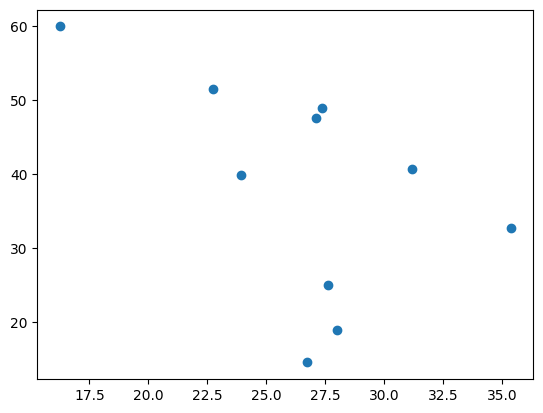

In [9]:
# Create a Scatter Plot for temperature vs. latitude
plt.scatter(weather_data["temp"], weather_data["lat"])

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [23]:
# Perform a linear regression on temperature vs. latitude

X = np.array(weather_data["lat"]).reshape(-1, 1)
y = np.array(weather_data["temp"])


model = LinearRegression()
model.fit(X, y)

# Get regression values

print(model.intercept_)
print(model.coef_)


33.260912317667774
[-0.17444822]


In [36]:
# Create line equation string
y_pred = model.predict(X)

In [31]:

from sklearn.metrics import r2_score


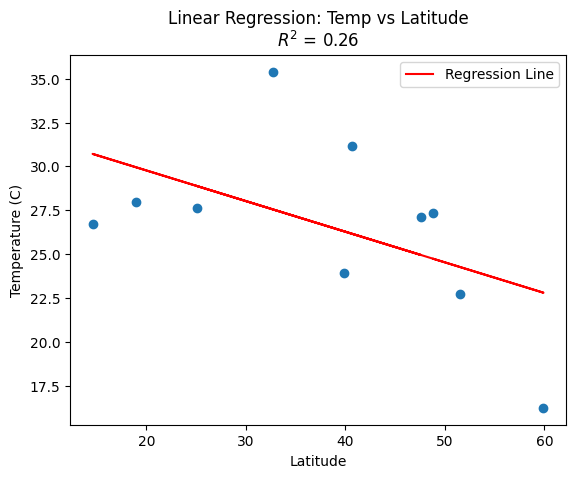

In [33]:
# Create Plot
plt.scatter(weather_data["lat"], weather_data["temp"])

plt.plot(weather_data["lat"], y_pred, color='red', label='Regression Line')


# Label plot and annotate the line equation

plt.xlabel("Latitude")
plt.ylabel("Temperature (C)")
plt.legend()



# Print r square value

r_squared = r2_score(y, y_pred)
plt.title(f"Linear Regression: Temp vs Latitude\n$R^2$ = {r_squared:.2f}")


# Show plot

plt.show()


In [42]:
# Use the line equation to predict the temperature for Florence at a latitude of 43.77 degrees
model.predict(np.array([[45.77]]))[0]


np.float64(25.276417390375997)

In [47]:
# Use API to determine actual temperature
city = "Florence"

response = requests.get(query_url + city).json()
lat = response['coord']['lat']
temp = (response['main']['temp'])

print(f"The latitude information received is: {lat}")
print(f"The temperature information received is: {temp}")

The latitude information received is: 43.7667
The temperature information received is: 32.58
